# Module 2 — Batting Analysis
**Unit III — Matplotlib & Seaborn | IPL 2008–2019**

Charts in this module:
1. Season-wise Both Innings Average (trend)
2. Phase-wise Run Rate (correct cricket formula)
3. Top 10 Batsmen by Total Runs
4. Phase Heatmap — Top Batsmen
5. Boundaries per Season (Fours vs Sixes)
6. Player Classification Scatter
7. ⭐ Strike Rate Acceleration by Balls Faced (NEW — broadcaster insight)
8. ⭐ Performance in Wins vs Losses (NEW — impact analysis)

## Setup — Libraries and Data

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

print('Libraries loaded')

Libraries loaded


In [25]:
# Load cleaned data from Module 1
deliveries   = pd.read_csv('deliveries_clean.csv')
legal        = pd.read_csv('legal_deliveries.csv')
player_stats = pd.read_csv('player_stats.csv')
matches      = pd.read_csv('matches_clean.csv')

print('deliveries shape :', deliveries.shape)
print('legal shape      :', legal.shape)
print('player_stats shape:', player_stats.shape)
print('matches shape    :', matches.shape)

deliveries shape : (178974, 25)
legal shape      : (173571, 25)
player_stats shape: (152, 10)
matches shape    : (752, 17)


In [26]:
deliveries.head(3)

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder,season,phase,is_dot_ball,is_boundary
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,NaN,NaN,NaN,2017,Powerplay,1,0
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,NaN,NaN,NaN,2017,Powerplay,1,0
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,4,0,4,NaN,NaN,NaN,2017,Powerplay,0,1


In [27]:
player_stats.head(3)

,batsman,total_runs,total_balls,fours,sixes,innings,dismissals,strike_rate,average,player_type
0,A Mishra,366,389,30,5,54,30.0,94.1,12.2,Support
1,A Symonds,974,750,74,41,36,26.0,129.9,37.5,Match Winner
2,AA Jhunjhunwala,217,210,19,5,15,14.0,103.3,15.5,Support


In [28]:
deliveries.info()

<class 'pandas.DataFrame'>
RangeIndex: 178974 entries, 0 to 178973
Data columns (total 25 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   match_id          178974 non-null  int64
 1   inning            178974 non-null  int64
 2   batting_team      178974 non-null  str  
 3   bowling_team      178974 non-null  str  
 4   over              178974 non-null  int64
 5   ball              178974 non-null  int64
 6   batsman           178974 non-null  str  
 7   non_striker       178974 non-null  str  
 8   bowler            178974 non-null  str  
 9   is_super_over     178974 non-null  int64
 10  wide_runs         178974 non-null  int64
 11  bye_runs          178974 non-null  int64
 12  legbye_runs       178974 non-null  int64
 13  noball_runs       178974 non-null  int64
 14  penalty_runs      178974 non-null  int64
 15  batsman_runs      178974 non-null  int64
 16  extra_runs        178974 non-null  int64
 17  total_runs        178

In [29]:
deliveries.describe()

,match_id,inning,over,ball,is_super_over,wide_runs,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,season,is_dot_ball,is_boundary
count,178974.000000,178974.000000,178974.000000,178974.000000,178974.0,178974.000000,178974.000000,178974.000000,178974.000000,178974.000000,178974.000000,178974.000000,178974.000000,178974.000000,178974.000000,178974.000000
mean,1801.845235,1.482070,10.167063,3.615587,0.0,0.036732,0.004934,0.021126,0.004163,0.000056,1.246567,0.067010,1.313576,2013.443986,0.351872,0.159437
std,3471.754217,0.500294,5.675565,1.806850,0.0,0.251212,0.116490,0.194909,0.070356,0.016714,1.607969,0.342571,1.605126,3.363949,0.477556,0.366084
min,1.000000,1.000000,1.000000,1.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2008.000000,0.000000,0.000000
25%,190.000000,1.000000,5.000000,2.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2011.000000,0.000000,0.000000
50%,379.000000,1.000000,10.000000,4.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,2013.000000,0.000000,0.000000
75%,567.000000,2.000000,15.000000,5.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,2016.000000,1.000000,0.000000
max,11415.000000,5.000000,20.000000,9.000000,0.0,5.000000,4.000000,5.000000,5.000000,5.000000,7.000000,7.000000,10.000000,2019.000000,1.000000,1.000000


In [30]:
deliveries.isnull().sum()

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batsman                  0
non_striker              0
bowler                   0
is_super_over            0
wide_runs                0
bye_runs                 0
legbye_runs              0
noball_runs              0
penalty_runs             0
batsman_runs             0
extra_runs               0
total_runs               0
player_dismissed    170154
dismissal_kind      170154
fielder             172534
season                   0
phase                    0
is_dot_ball              0
is_boundary              0
dtype: int64

---
## Chart 1 — Season-wise Average Score: Both Innings
*Is IPL batting getting more aggressive over the years? Is defending getting harder?*

**Broadcaster angle:** Analysts compare 1st vs 2nd innings trends to understand whether
totals are going up and whether chasing has become easier in modern IPL.

In [31]:
# Total runs per match per innings
season_scores = deliveries.groupby(['match_id', 'season', 'inning'])['total_runs'].sum().reset_index()

# Separate innings and compute season averages
first_innings  = season_scores[season_scores['inning'] == 1]
second_innings = season_scores[season_scores['inning'] == 2]

avg_inn1 = first_innings.groupby('season')['total_runs'].mean().round(1)
avg_inn2 = second_innings.groupby('season')['total_runs'].mean().round(1)

print('Season | Inn1 Avg | Inn2 Avg')
for s in avg_inn1.index:
    print(f'{s}  |   {avg_inn1[s]}   |   {avg_inn2[s]}')

Season | Inn1 Avg | Inn2 Avg
2008  |   161.0   |   148.3
2009  |   150.3   |   136.1
2010  |   164.8   |   149.6
2011  |   152.4   |   139.3
2012  |   157.5   |   145.9
2013  |   155.9   |   140.7
2014  |   163.1   |   152.1
2015  |   166.3   |   146.9
2016  |   162.6   |   151.8
2017  |   165.8   |   152.3
2018  |   179.8   |   165.2
2019  |   173.6   |   163.5


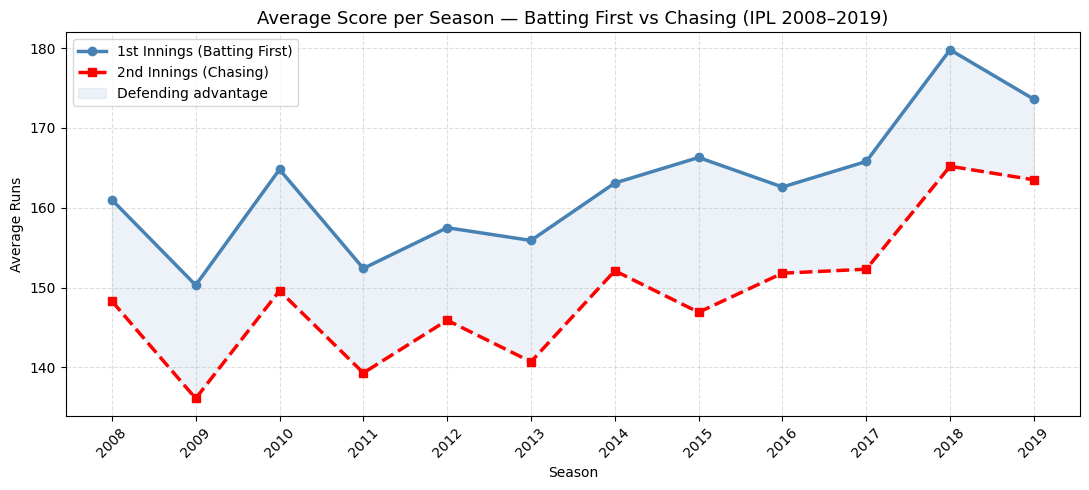


Insight: On average, teams batting first score 13.5 more runs than chasing teams.
The gap narrowing in 2018-2019 suggests modern IPL teams are better at chasing.


In [32]:
plt.figure(figsize=(11, 5))

plt.plot(avg_inn1.index, avg_inn1.values, color='steelblue', linewidth=2.5,
         marker='o', markersize=6, label='1st Innings (Batting First)')
plt.plot(avg_inn2.index, avg_inn2.values, color='red', linewidth=2.5,
         marker='s', markersize=6, label='2nd Innings (Chasing)', linestyle='--')

# Shade the gap between innings to show defending advantage
plt.fill_between(avg_inn1.index, avg_inn1.values, avg_inn2.values,
                 alpha=0.1, color='steelblue', label='Defending advantage')

plt.title('Average Score per Season — Batting First vs Chasing (IPL 2008–2019)', fontsize=13)
plt.xlabel('Season')
plt.ylabel('Average Runs')
plt.xticks(avg_inn1.index, rotation=45)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('chart1_both_innings_trend.png', dpi=150)
plt.show()

# Insight print
overall_gap = (avg_inn1 - avg_inn2).mean().round(1)
print(f'\nInsight: On average, teams batting first score {overall_gap} more runs than chasing teams.')
print('The gap narrowing in 2018-2019 suggests modern IPL teams are better at chasing.')

---
## Chart 2 — Phase-wise Run Rate
*Powerplay vs Middle vs Death — how does run rate change across match phases?*

**Cricket note:** Run rate = total runs (including extras) per legal ball × 6.
Extras like wides and no-balls count toward team score, so they are included in total_runs.
But the ball count uses only legal deliveries — wides don't count as a ball faced.

In [33]:
# Total runs per phase (includes all extras — they count toward team score)
phase_total_runs = deliveries.groupby('phase')['total_runs'].sum()

# Legal ball count per phase (wides excluded — they don't use up a legal delivery)
phase_legal_balls = legal.groupby('phase')['ball'].count()

phase_order = ['Powerplay', 'Middle', 'Death']

phase_rr = pd.Series(dtype=float)
for phase in phase_order:
    rr = (phase_total_runs[phase] / phase_legal_balls[phase]) * 6
    phase_rr[phase] = round(rr, 2)

print('Run Rate by Phase (Runs per Over):')
print(phase_rr)

Run Rate by Phase (Runs per Over):
Powerplay    7.67
Middle       7.64
Death        9.77
dtype: float64


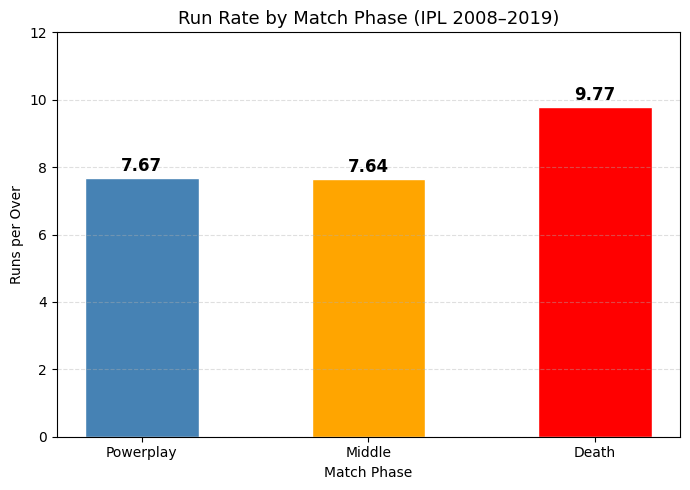


Insight: Death overs produce significantly more runs per over.
Powerplay and Middle are surprisingly similar — batsmen play cautiously in both.


In [34]:
plt.figure(figsize=(7, 5))
bars = plt.bar(phase_rr.index, phase_rr.values,
               color=['steelblue', 'orange', 'red'], width=0.5, edgecolor='white')

# Add value labels on bars
for bar, val in zip(bars, phase_rr.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             str(val), ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Run Rate by Match Phase (IPL 2008–2019)', fontsize=13)
plt.xlabel('Match Phase')
plt.ylabel('Runs per Over')
plt.ylim(0, 12)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('chart2_phase_runrate.png', dpi=150)
plt.show()

print('\nInsight: Death overs produce significantly more runs per over.')
print('Powerplay and Middle are surprisingly similar — batsmen play cautiously in both.')

---
## Chart 3 — Top 10 Batsmen by Total Runs
*Who has scored the most runs across 12 seasons of IPL?*

Filter: Minimum 200 legal balls faced (removes players with very few innings)

In [35]:
# player_stats already filtered to min 200 balls in Module 1
top10 = player_stats.nlargest(10, 'total_runs').sort_values('total_runs')
print(top10[['batsman', 'total_runs', 'total_balls', 'strike_rate', 'average']].to_string())

            batsman  total_runs  total_balls  strike_rate  average
41        G Gambhir        4220         3404        124.0     31.3
3    AB de Villiers        4403         2906        151.5     42.3
116      RV Uthappa        4422         3382        130.8     28.2
91         MS Dhoni        4450         3215        138.4     37.7
23         CH Gayle        4508         2970        151.8     41.4
118        S Dhawan        4604         3670        125.4     33.9
28        DA Warner        4722         3305        142.9     41.8
112       RG Sharma        4902         3744        130.9     30.3
125        SK Raina        5382         3914        137.5     33.6
143         V Kohli        5421         4112        131.8     35.7


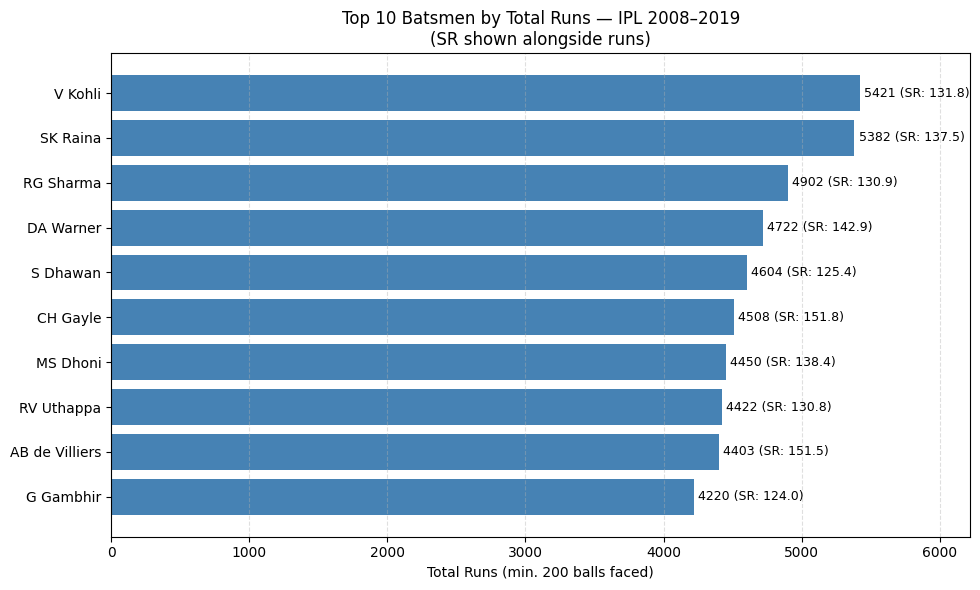

In [36]:
plt.figure(figsize=(10, 6))
bars = plt.barh(top10['batsman'], top10['total_runs'], color='steelblue')

for bar, (_, row) in zip(bars, top10.iterrows()):
    plt.text(bar.get_width() + 30,
             bar.get_y() + bar.get_height()/2,
             f"{row['total_runs']} (SR: {row['strike_rate']})",
             va='center', fontsize=9)

plt.title('Top 10 Batsmen by Total Runs — IPL 2008–2019\n(SR shown alongside runs)', fontsize=12)
plt.xlabel('Total Runs (min. 200 balls faced)')
plt.xlim(0, max(top10['total_runs']) + 800)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

---
## Chart 4 — Batsman Phase Heatmap
*Which batsmen dominate which phase? Shown as Strike Rate per phase.*

**Why Strike Rate and not average:** Phase-level average doesn't make sense
(you can't calculate dismissals per phase cleanly). Strike rate per phase shows
how aggressively each player attacks in that phase — which is the actual question.

In [37]:
# Use legal deliveries — wides excluded (strike rate uses balls faced)
top_bats = player_stats.nlargest(10, 'total_runs')['batsman'].tolist()
phase_data = legal[legal['batsman'].isin(top_bats)]

# Strike rate = (runs scored / balls faced) * 100
phase_runs  = phase_data.groupby(['batsman', 'phase'])['batsman_runs'].sum()
phase_balls = phase_data.groupby(['batsman', 'phase'])['ball'].count()
phase_sr    = (phase_runs / phase_balls * 100).unstack()
phase_sr    = phase_sr[['Powerplay', 'Middle', 'Death']].round(1)

print('Strike Rate by Phase — Top 10 Batsmen:')
print(phase_sr.to_string())

Strike Rate by Phase — Top 10 Batsmen:
phase           Powerplay  Middle  Death
batsman                                 
AB de Villiers      121.2   134.9  223.8
CH Gayle            135.0   164.3  214.5
DA Warner           139.7   137.4  190.3
G Gambhir           122.1   123.7  145.2
MS Dhoni             80.0   104.6  178.8
RG Sharma           113.7   118.5  182.5
RV Uthappa          124.6   128.1  174.4
S Dhawan            122.2   124.3  154.7
SK Raina            134.1   131.3  173.2
V Kohli             115.4   125.7  192.3


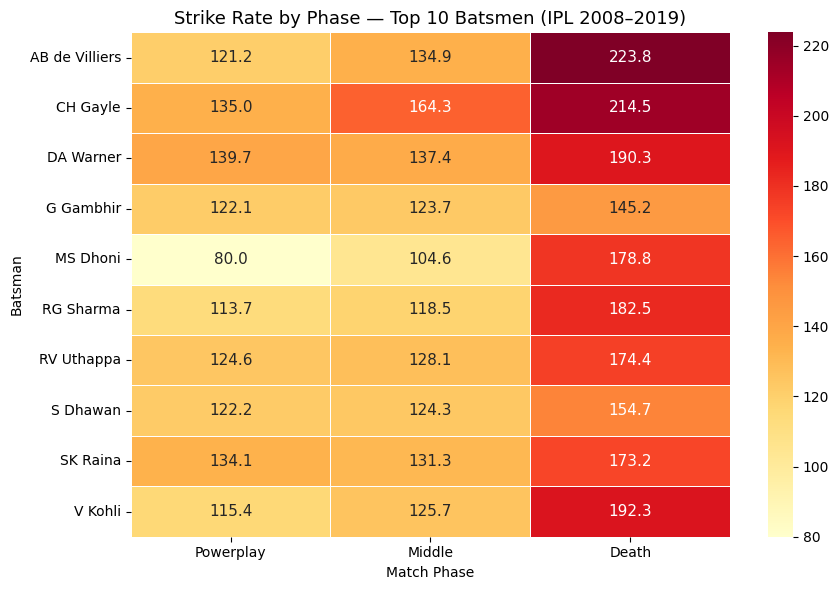


Insight: Red cells show dominant phases for each player.
Death overs SR reveals true finishers vs anchors.


In [38]:
plt.figure(figsize=(9, 6))
sns.heatmap(phase_sr, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, annot_kws={'size': 11})
plt.title('Strike Rate by Phase — Top 10 Batsmen (IPL 2008–2019)', fontsize=13)
plt.xlabel('Match Phase')
plt.ylabel('Batsman')
plt.tight_layout()
plt.savefig('chart4_phase_heatmap.png', dpi=150)
plt.show()

print('\nInsight: Red cells show dominant phases for each player.')
print('Death overs SR reveals true finishers vs anchors.')

---
## Chart 5 — Boundaries per Season (Stacked Bar)
*How has six-hitting evolved over 12 years of IPL?*

In [39]:
boundaries = deliveries[deliveries['batsman_runs'].isin([4, 6])]
boundary_counts = boundaries.groupby(['season', 'batsman_runs']).size().unstack(fill_value=0)
boundary_counts.columns = ['Fours', 'Sixes']
print(boundary_counts)

        Fours  Sixes
season              
2008     1703    623
2009     1317    506
2010     1708    585
2011     1916    639
2012     1911    733
2013     2052    675
2014     1562    714
2015     1607    692
2016     1633    639
2017     1611    705
2018     1673    869
2019     1684    778


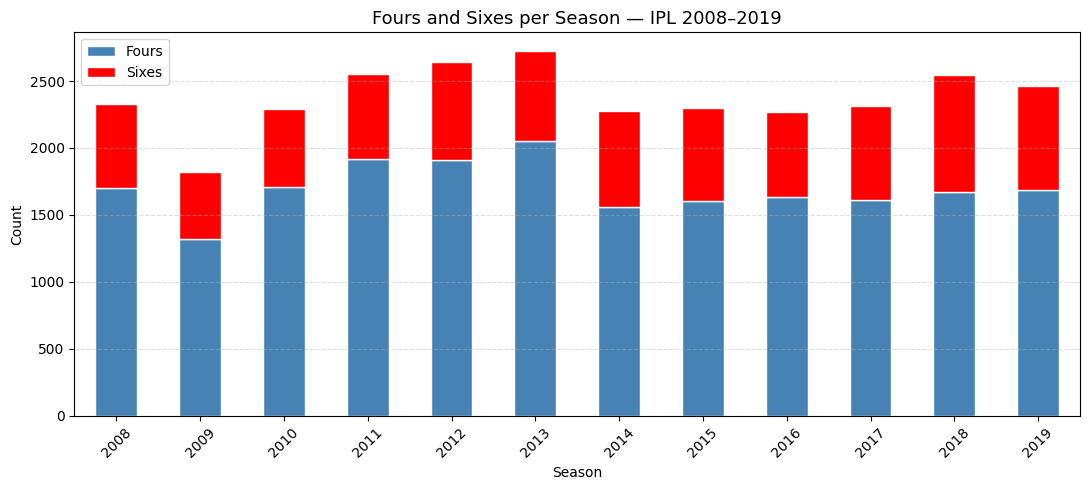


Six-hitting trend:
season
2008    623
2009    506
2010    585
2011    639
2012    733
2013    675
2014    714
2015    692
2016    639
2017    705
2018    869
2019    778
Name: Sixes, dtype: int64


In [40]:
boundary_counts.plot(kind='bar', stacked=True, figsize=(11, 5),
                     color=['steelblue', 'red'], edgecolor='white')
plt.title('Fours and Sixes per Season — IPL 2008–2019', fontsize=13)
plt.xlabel('Season')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(loc='upper left', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('chart5_boundaries_season.png', dpi=150)
plt.show()

# Sixes trend
print('\nSix-hitting trend:')
print(boundary_counts['Sixes'])

---
## Chart 6 — Player Classification Scatter
*Aggressive vs Anchor vs Match Winner vs Support — rule-based classification*

**How classification works:** Players are divided into 4 roles using median
thresholds for Strike Rate and Average. This is a rule-based approach — no ML needed.
- **Match Winner:** High SR + High Average (elite all-round batsmen)
- **Aggressive:** High SR + Low Average (big hitters, low consistency)
- **Anchor:** Low SR + High Average (consistent, slower run-makers)
- **Support:** Low SR + Low Average (utility players)

In [41]:
print('Player type distribution:')
print(player_stats['player_type'].value_counts())
print()
print('Classification thresholds used:')
print('Strike Rate median:', player_stats['strike_rate'].median())
print('Average median    :', player_stats['average'].median())

Player type distribution:
player_type
Support         51
Match Winner    51
Anchor          25
Aggressive      25
Name: count, dtype: int64

Classification thresholds used:
Strike Rate median: 127.35
Average median    : 25.1


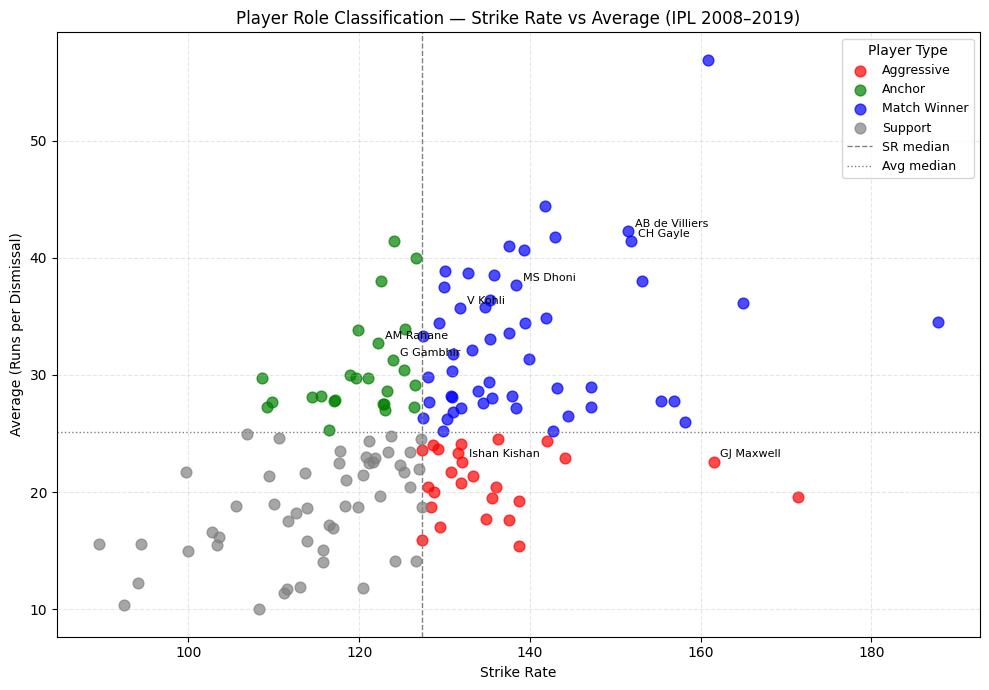

In [42]:
colors = {'Match Winner': 'blue', 'Aggressive': 'red', 'Anchor': 'green', 'Support': 'gray'}

plt.figure(figsize=(10, 7))

for ptype, group in player_stats.groupby('player_type'):
    plt.scatter(group['strike_rate'], group['average'],
                c=colors[ptype], label=ptype, alpha=0.7, s=60)

# Label a few notable players
notable = ['V Kohli', 'MS Dhoni', 'CH Gayle', 'AB de Villiers', 'AM Rahane', 'GJ Maxwell', 'Ishan Kishan', 'G Gambhir']
for _, row in player_stats[player_stats['batsman'].isin(notable)].iterrows():
    plt.annotate(row['batsman'], (row['strike_rate'], row['average']),
                 textcoords='offset points', xytext=(5, 3), fontsize=8)

plt.axvline(player_stats['strike_rate'].median(), color='gray', linestyle='--', linewidth=1, label='SR median')
plt.axhline(player_stats['average'].median(), color='gray', linestyle=':', linewidth=1, label='Avg median')

plt.title('Player Role Classification — Strike Rate vs Average (IPL 2008–2019)', fontsize=12)
plt.xlabel('Strike Rate')
plt.ylabel('Average (Runs per Dismissal)')
plt.legend(title='Player Type', fontsize=9)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('chart6_player_classification.png', dpi=150)
plt.show()

---
## Chart 7 — ⭐ Strike Rate Acceleration by Balls Faced
*How does a batsman's strike rate change as they get more set at the crease?*

**Broadcaster angle:** Commentators often say "he's taken his time to settle."
This chart proves it with data — showing exactly when each player starts accelerating.
The ball buckets (1–10, 11–20, 21–30, 31+) mirror how broadcasters segment innings.

In [43]:
# Selected players for comparison
selected_players = ['V Kohli', 'MS Dhoni', 'CH Gayle', 'RG Sharma', 'AB de Villiers', 'SK Raina']

# For each player, compute their ball-in-innings number per match
# Then bucket by 1-10, 11-20, 21-30, 31+ and compute SR in each bucket

bucket_labels = ['1–10', '11–20', '21–30', '31+']
bucket_ranges = [(1, 10), (11, 20), (21, 30), (31, 999)]

sr_acceleration = {}

for player in selected_players:
    bat_data = legal[legal['batsman'] == player].copy()

    # Number each ball sequentially within each match innings
    innings_list = []
    for mid, grp in bat_data.groupby('match_id'):
        grp = grp.reset_index(drop=True)
        grp['ball_in_innings'] = range(1, len(grp) + 1)
        innings_list.append(grp)

    if len(innings_list) == 0:
        continue

    bat_df = pd.concat(innings_list)

    sr_per_bucket = []
    for lo, hi in bucket_ranges:
        subset = bat_df[(bat_df['ball_in_innings'] >= lo) & (bat_df['ball_in_innings'] <= hi)]
        if len(subset) >= 30:  # need enough balls for meaningful SR
            sr = round(subset['batsman_runs'].sum() / len(subset) * 100, 1)
        else:
            sr = None
        sr_per_bucket.append(sr)

    sr_acceleration[player] = sr_per_bucket

print('Strike Rate by Balls Faced Bucket:')
print(f'{"Batsman":<20} {"1-10":>8} {"11-20":>8} {"21-30":>8} {"31+":>8}')
for player, srs in sr_acceleration.items():
    vals = [str(s) if s else '-' for s in srs]
    print(f'{player:<20} {vals[0]:>8} {vals[1]:>8} {vals[2]:>8} {vals[3]:>8}')

Strike Rate by Balls Faced Bucket:
Batsman                  1-10    11-20    21-30      31+
V Kohli                 109.7    129.2    130.2    178.6
MS Dhoni                114.3    144.9    168.4    225.0
CH Gayle                115.7    162.4    159.4    194.2
RG Sharma               102.2    138.7    154.3    173.3
AB de Villiers          123.8    148.9    171.7    212.9
SK Raina                119.5    144.1    147.7    168.7


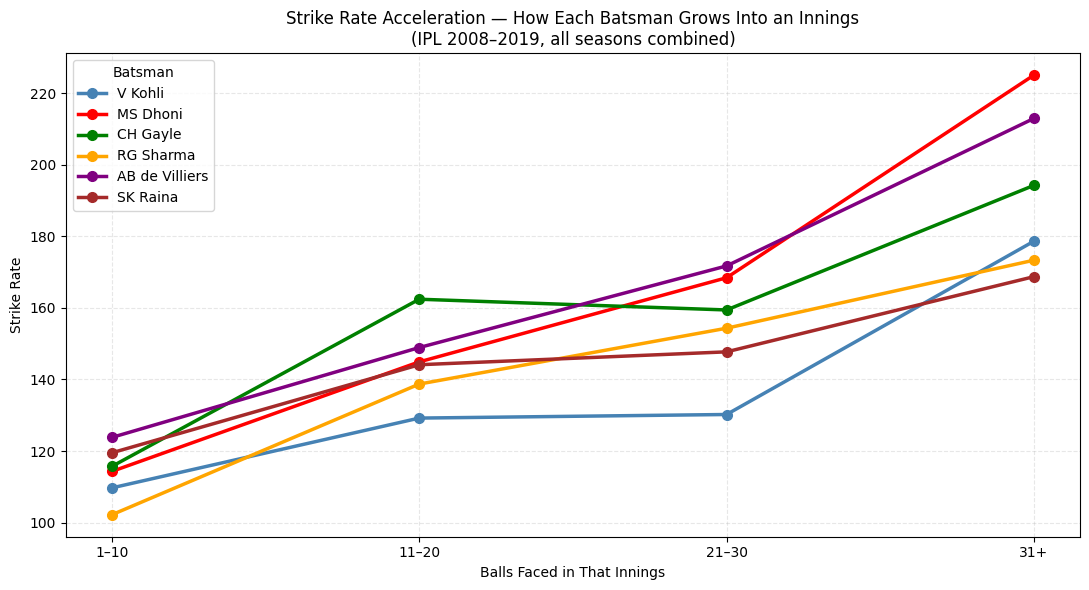


Insight:
Players whose SR jumps sharply at 31+ are true match finishers.
Players with high SR even at 1-10 are natural aggressors (e.g. Gayle).


In [44]:
plt.figure(figsize=(11, 6))

line_colors = ['steelblue', 'red', 'green', 'orange', 'purple', 'brown']

for i, (player, srs) in enumerate(sr_acceleration.items()):
    # Only plot buckets where we have data
    valid_x = []
    valid_y = []
    for j, sr in enumerate(srs):
        if sr is not None:
            valid_x.append(bucket_labels[j])
            valid_y.append(sr)

    plt.plot(valid_x, valid_y, marker='o', linewidth=2.5, markersize=7,
             color=line_colors[i], label=player)

plt.title('Strike Rate Acceleration — How Each Batsman Grows Into an Innings\n(IPL 2008–2019, all seasons combined)', fontsize=12)
plt.xlabel('Balls Faced in That Innings')
plt.ylabel('Strike Rate')
plt.legend(fontsize=10, title='Batsman')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('chart7_sr_acceleration.png', dpi=150)
plt.show()

print('\nInsight:')
print('Players whose SR jumps sharply at 31+ are true match finishers.')
print('Players with high SR even at 1-10 are natural aggressors (e.g. Gayle).')

---
## Chart 8 — ⭐ Performance in Wins vs Losses
*Who actually performs when it matters — in matches their team wins?*

**Broadcaster angle:** A player's overall average looks good, but the real question
analysts ask is: does he score when his team needs it most? This chart separates
genuine match-winners from volume scorers.

In [45]:
# Merge legal deliveries with match winner
merged = legal.merge(matches[['id', 'winner']], left_on='match_id', right_on='id')

# Did the batting team win this match?
merged['bat_team_won'] = (merged['batting_team'] == merged['winner']).astype(int)

# Compute SR in wins and losses per batsman
perf = merged.groupby(['batsman', 'bat_team_won']).agg(
    runs  = ('batsman_runs', 'sum'),
    balls = ('ball', 'count')
).reset_index()

perf['sr'] = (perf['runs'] / perf['balls'] * 100).round(1)

# Pivot to get win/loss side by side
perf_pivot = perf.pivot(index='batsman', columns='bat_team_won', values='sr')
balls_pivot = perf.pivot(index='batsman', columns='bat_team_won', values='balls')

# Only keep players with enough balls in both outcomes (100 minimum)
perf_pivot = perf_pivot[balls_pivot.min(axis=1) >= 100].dropna()
perf_pivot.columns = ['SR in Losses', 'SR in Wins']
perf_pivot['Difference'] = (perf_pivot['SR in Wins'] - perf_pivot['SR in Losses']).round(1)

# Top 12 by SR in wins
top_performers = perf_pivot.nlargest(12, 'SR in Wins')
print(top_performers.to_string())

                SR in Losses  SR in Wins  Difference
batsman                                             
AD Russell             175.9       203.7        27.8
SP Narine              140.3       192.6        52.3
GJ Maxwell             138.1       179.6        41.5
RR Pant                156.3       172.9        16.6
HH Pandya              142.3       170.4        28.1
V Sehwag               135.2       168.2        33.0
ST Jayasuriya          119.7       166.1        46.4
JA Morkel              131.6       165.4        33.8
CH Gayle               133.7       164.8        31.1
AB de Villiers         137.5       163.6        26.1
CJ Anderson            105.3       163.5        58.2
JC Buttler             138.0       163.5        25.5


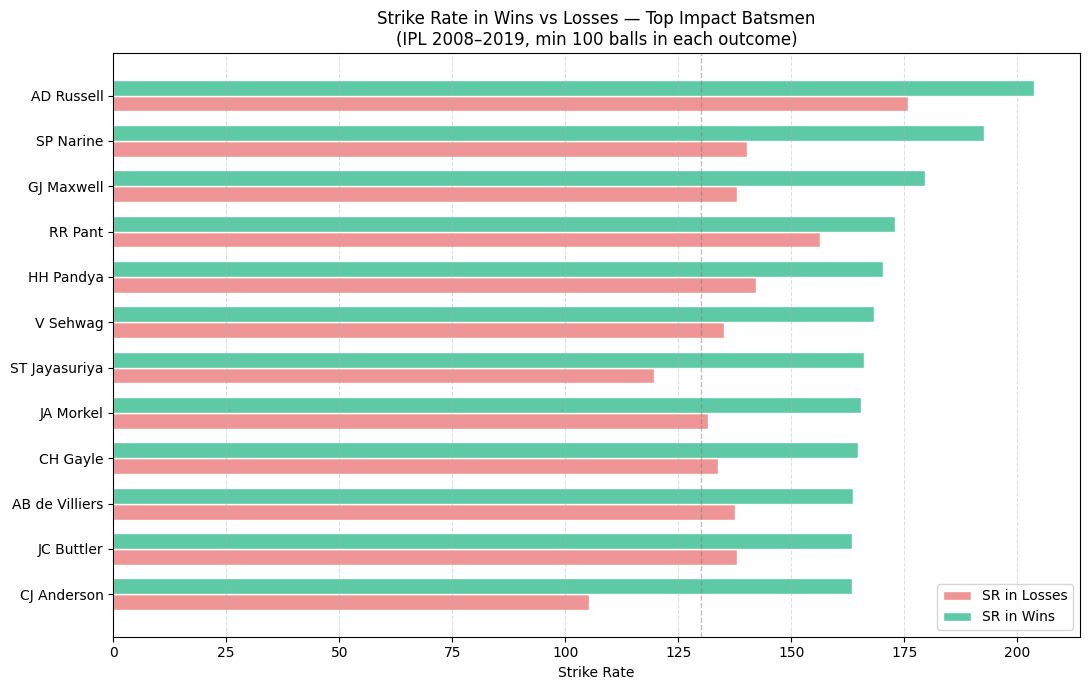


Insight:
Players where green bar is much longer = genuine match-winners.
Players where bars are similar = consistent performers regardless of result.


In [46]:
# Sort by SR in wins for plotting
top_performers = top_performers.sort_values('SR in Wins')

x = range(len(top_performers))
width = 0.35

plt.figure(figsize=(11, 7))
plt.barh([i - width/2 for i in x], top_performers['SR in Losses'],
         width, label='SR in Losses', color='#F09595', edgecolor='white')
plt.barh([i + width/2 for i in x], top_performers['SR in Wins'],
         width, label='SR in Wins',   color='#5DCAA5', edgecolor='white')

plt.yticks(list(x), top_performers.index)
plt.axvline(130, color='gray', linestyle='--', linewidth=1, alpha=0.5)
plt.title('Strike Rate in Wins vs Losses — Top Impact Batsmen\n(IPL 2008–2019, min 100 balls in each outcome)', fontsize=12)
plt.xlabel('Strike Rate')
plt.legend(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('chart8_wins_vs_losses.png', dpi=150)
plt.show()

print('\nInsight:')
print('Players where green bar is much longer = genuine match-winners.')
print('Players where bars are similar = consistent performers regardless of result.')